# Introvert vs Extrovert Personality Prediction

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
import json
from pathlib import Path
import joblib
import os

In [66]:
DATA_PATH = "data/personality_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [67]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("Missing values:")
print(df.isna().sum())
print("Target distribution:")
print(df["Personality"].value_counts())

Dataset shape: (2900, 8)
Columns:
['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
Missing values:
Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64
Target distribution:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


In [68]:
df_clean = df.copy()

TARGET = "Personality"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categorical features: ['Stage_fear', 'Drained_after_socializing']


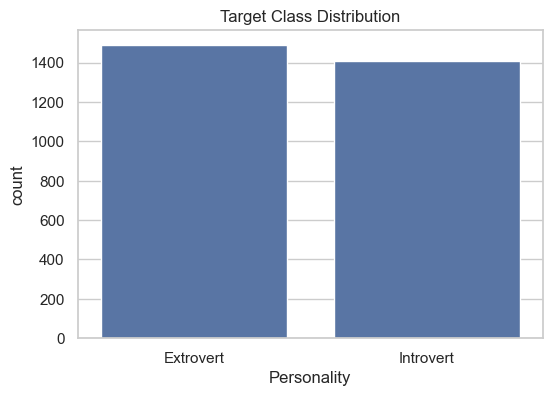

In [69]:
# Target balance
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Personality")
plt.title("Target Class Distribution")
plt.show()

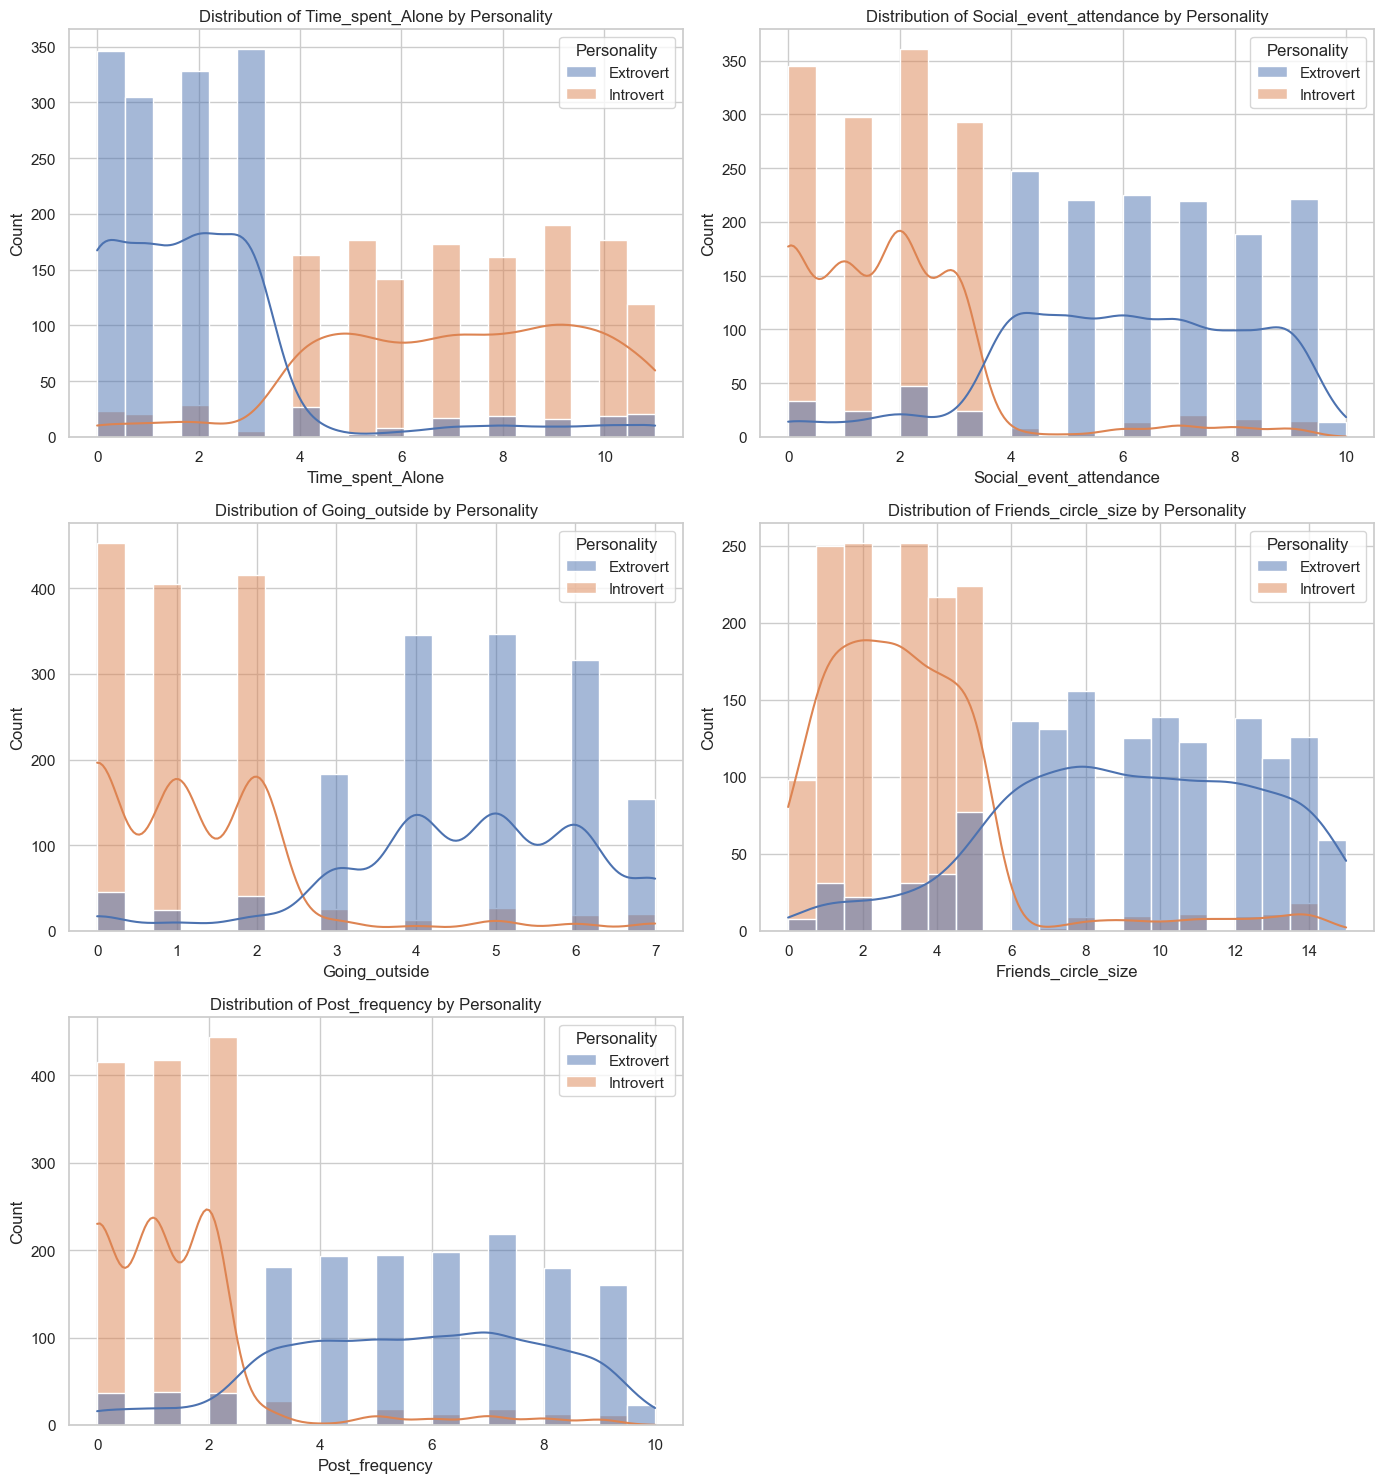

In [70]:
# Numerical feature distributions by target
n_cols = 2
n_rows = math.ceil(len(numeric_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(
        data=df_clean,
        x=col,
        hue="Personality",
        kde=True,
        bins=20,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Personality")
# Remove unused subplots
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

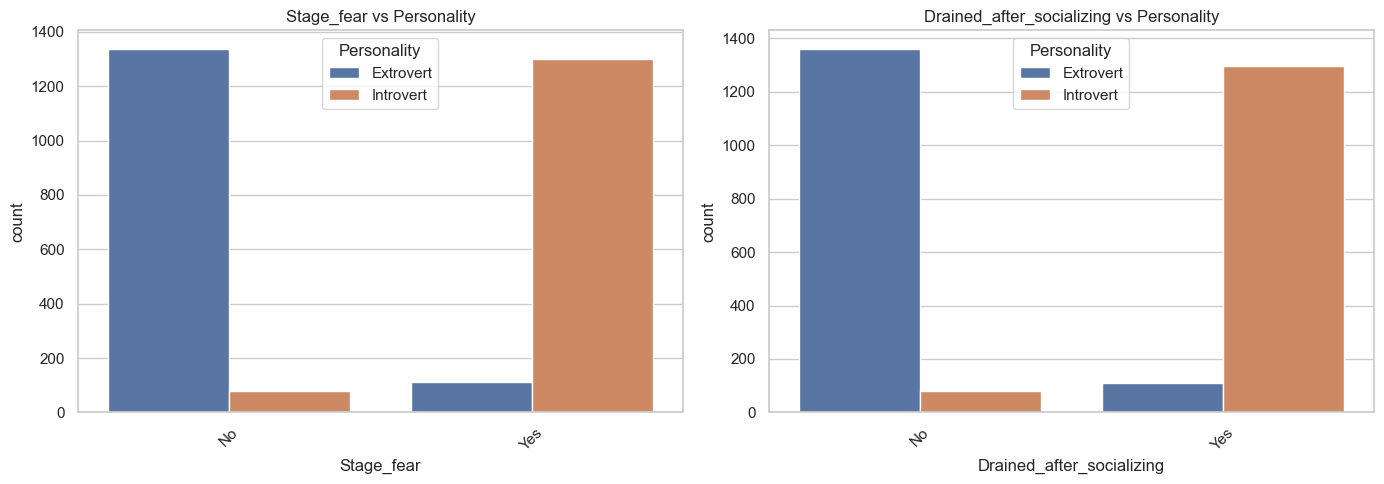

In [71]:
# Categorical feature relationships
n_cols = 2
n_rows = math.ceil(len(categorical_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="Personality",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Personality")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

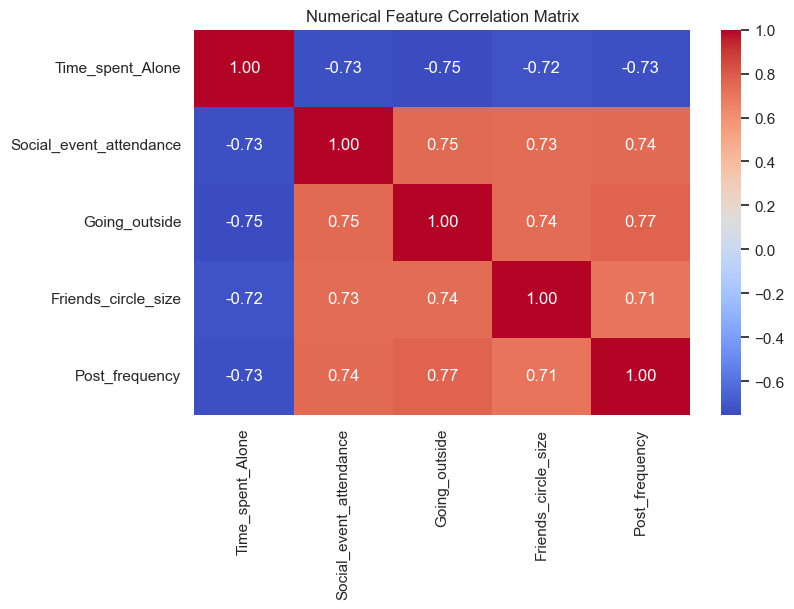

In [72]:
# Correlation check for numerical variables
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation Matrix")
plt.show()

In [73]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric",      numeric_transformer,     numeric_features),
    ("categorical",  categorical_transformer, categorical_features),
])

In [74]:
# Compare multiple models using stratified 5-fold cross-validation
candidate_models = {
    "Logistic Regression":  LogisticRegression(max_iter=2000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   class_weight="balanced",
                                                   random_state=RANDOM_STATE),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                                                 random_state=RANDOM_STATE),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       max_depth=4,
                                                       random_state=RANDOM_STATE),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, clf in candidate_models.items():
    pipe   = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=["accuracy", "f1_weighted", "roc_auc_ovo_weighted"],
        n_jobs=-1,
    )
    results.append({
        "Model":              name,
        "CV Accuracy (mean)": round(scores["test_accuracy"].mean(), 4),
        "CV Accuracy (std)":  round(scores["test_accuracy"].std(),  4),
        "CV F1 (mean)":       round(scores["test_f1_weighted"].mean(), 4),
        "CV ROC-AUC (mean)":  round(scores["test_roc_auc_ovo_weighted"].mean(), 4),
    })
    print(f"  {name:<25s} accuracy={scores['test_accuracy'].mean():.4f}  "
          f"f1={scores['test_f1_weighted'].mean():.4f}  "
          f"roc_auc={scores['test_roc_auc_ovo_weighted'].mean():.4f}")

results_df = pd.DataFrame(results).sort_values("CV F1 (mean)", ascending=False)
display(results_df)


  Logistic Regression       accuracy=0.9266  f1=0.9266  roc_auc=0.9311
  Random Forest             accuracy=0.9345  f1=0.9345  roc_auc=0.9646
  Extra Trees               accuracy=0.9193  f1=0.9193  roc_auc=0.9316
  Gradient Boosting         accuracy=0.9286  f1=0.9286  roc_auc=0.9633


,Model,CV Accuracy (mean),CV Accuracy (std),CV F1 (mean),CV ROC-AUC (mean)
1,Random Forest,0.9345,0.0102,0.9345,0.9646
3,Gradient Boosting,0.9286,0.0053,0.9286,0.9633
0,Logistic Regression,0.9266,0.0085,0.9266,0.9311
2,Extra Trees,0.9193,0.0048,0.9193,0.9316


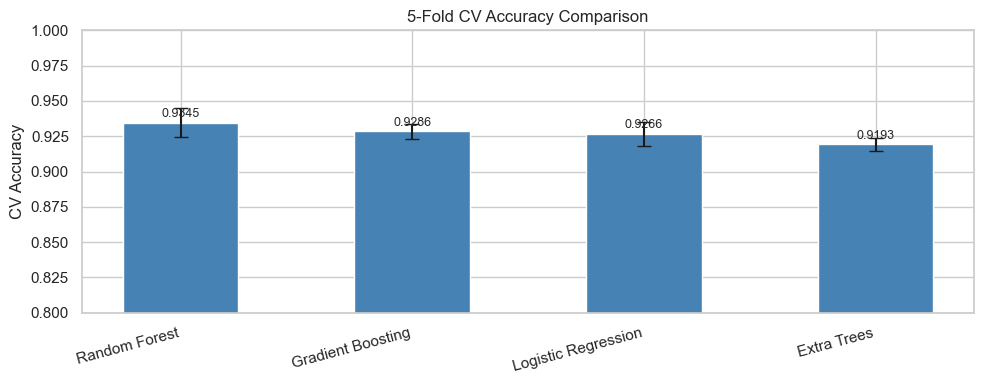

In [75]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df["CV Accuracy (mean)"],
              yerr=results_df["CV Accuracy (std)"],
              capsize=5, color="steelblue", width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("CV Accuracy")
ax.set_title("5-Fold CV Accuracy Comparison")
for bar in bars:
    ax.annotate(f"{bar.get_height():.4f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9)
plt.tight_layout()
plt.show()


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")

final_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_STATE,
    )),
])

final_model.fit(X_train, y_train)
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

pos_idx = list(final_model.classes_).index("Extrovert")

print("\n── Test-set metrics ─────────────────────────────────────────")
print(f"  Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Weighted Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"  Weighted Recall    : {recall_score(y_test, y_pred,    average='weighted'):.4f}")
print(f"  Weighted F1        : {f1_score(y_test, y_pred,        average='weighted'):.4f}")
print(f"  ROC-AUC            : {roc_auc_score((y_test=='Extrovert').astype(int), y_proba[:, pos_idx]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Train: 2320 samples  |  Test: 580 samples

── Test-set metrics ─────────────────────────────────────────
  Accuracy           : 0.9121
  Weighted Precision : 0.9133
  Weighted Recall    : 0.9121
  Weighted F1        : 0.9121
  ROC-AUC            : 0.9537

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.89      0.91       298
   Introvert       0.89      0.94      0.91       282

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580



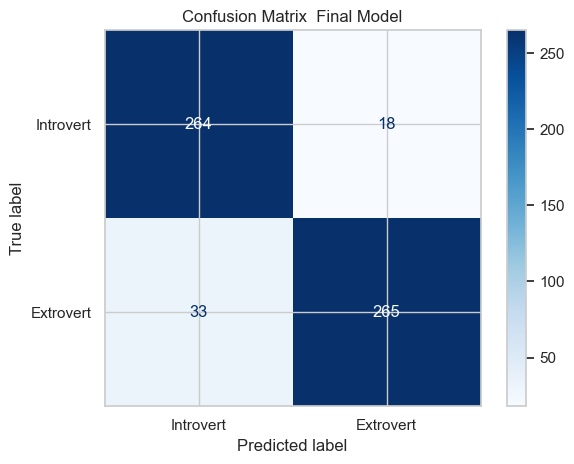

In [77]:
labels = ["Introvert", "Extrovert"]
cm     = confusion_matrix(y_test, y_pred, labels=labels)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix  Final Model")
plt.tight_layout()
plt.show()


,feature,importance
0,categorical__Drained_after_socializing_Yes,0.880326
1,numeric__Post_frequency,0.055029
2,numeric__Friends_circle_size,0.020576
3,numeric__Time_spent_Alone,0.016751
4,numeric__Social_event_attendance,0.015565
5,numeric__Going_outside,0.011559
6,categorical__Stage_fear_Yes,0.000194


C:\Users\User\AppData\Local\Temp\ipykernel_31988\3624531483.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="viridis")


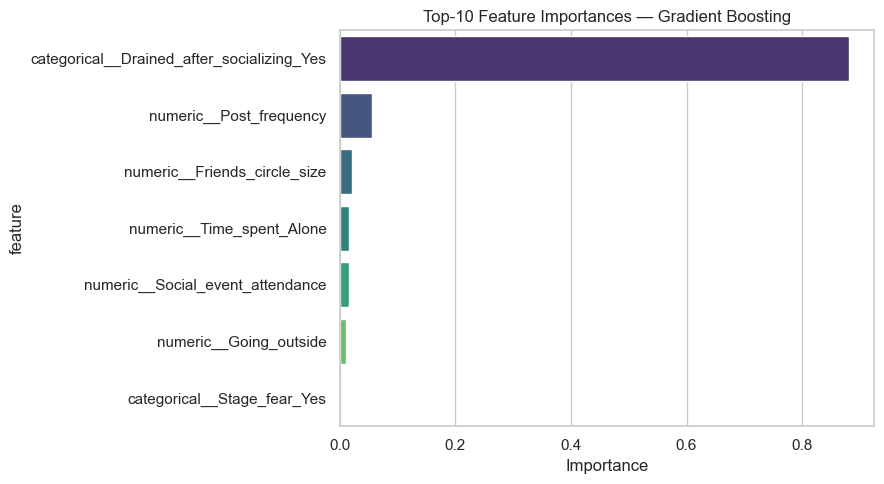

In [78]:
# Extract transformed feature names and feature importances
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
importances   = final_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top-10 Feature Importances — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [79]:
# Save final model and outputs
MODEL_DIR = Path(os.getcwd()) / "models"
DOCS_DIR  = Path(os.getcwd()) / "docs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True,  exist_ok=True)

# Save trained pipeline
joblib.dump(final_model, MODEL_DIR / "personality_model.joblib")

# Save CV comparison table
results_df.to_csv(DOCS_DIR / "model_comparison.csv", index=False)

# Save test-set metrics as JSON
metrics = {
    "best_model":               "Gradient Boosting Classifier",
    "test_accuracy":            float(accuracy_score(y_test, y_pred)),
    "test_f1_weighted":         float(f1_score(y_test, y_pred,        average="weighted")),
    "test_precision_weighted":  float(precision_score(y_test, y_pred, average="weighted")),
    "test_recall_weighted":     float(recall_score(y_test, y_pred,    average="weighted")),
    "test_roc_auc":             float(roc_auc_score((y_test == "Extrovert").astype(int),
                                                    y_proba[:, pos_idx])),
    "confusion_matrix_labels":  labels,
    "confusion_matrix":         cm.tolist(),
    "features":                 X.columns.tolist(),
    "target":                   TARGET,
    "classes":                  final_model.classes_.tolist(),
}

with open(DOCS_DIR / "final_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print(f"  {MODEL_DIR / 'personality_model.joblib'}")
print(f"  {DOCS_DIR  / 'model_comparison.csv'}")
print(f"  {DOCS_DIR  / 'final_model_metrics.json'}")
print("\nFinal metrics summary:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")


Saved:
  c:\Users\User\Decryptogen_Assessment\models\personality_model.joblib
  c:\Users\User\Decryptogen_Assessment\docs\model_comparison.csv
  c:\Users\User\Decryptogen_Assessment\docs\final_model_metrics.json

Final metrics summary:
  test_accuracy: 0.9121
  test_f1_weighted: 0.9121
  test_precision_weighted: 0.9133
  test_recall_weighted: 0.9121
  test_roc_auc: 0.9537


In [80]:
import requests

URL = "https://personality-prediction-api-1.onrender.com/predict"

# Test 1: Introvert profile
introvert = {
    "Time_spent_Alone": 7,
    "Stage_fear": "Yes",
    "Social_event_attendance": 2,
    "Going_outside": 3,
    "Drained_after_socializing": "Yes",
    "Friends_circle_size": 4,
    "Post_frequency": 2
}

# Test 2: Extrovert profile
extrovert = {
    "Time_spent_Alone": 1,
    "Stage_fear": "No",
    "Social_event_attendance": 9,
    "Going_outside": 7,
    "Drained_after_socializing": "No",
    "Friends_circle_size": 12,
    "Post_frequency": 8
}

for label, payload in [("Introvert", introvert), ("Extrovert", extrovert)]:
    response = requests.post(URL, json=payload)
    print(f"\nExpected : {label}")
    print(f"Status   : {response.status_code}")
    print(f"Result   : {response.json()}")


Expected : Introvert
Status   : 200
Result   : {'prediction': 'Introvert', 'confidence': 0.9539, 'probabilities': {'Extrovert': 0.0461, 'Introvert': 0.9539}}

Expected : Extrovert
Status   : 200
Result   : {'prediction': 'Extrovert', 'confidence': 0.8147, 'probabilities': {'Extrovert': 0.8147, 'Introvert': 0.1853}}
